# VAMPS — Fiji Pine Forest Example

This notebook reproduces the **fiji** example: a Fiji pine forest simulation
with 77 soil layers, 61 daily timesteps, Van Genuchten soil, and a
Penman-Monteith canopy.

**Requirements**
```
pip install -e ..[notebook]   # from the repo root
```
The `vamps` binary must be on your PATH, or set `VAMPS_BINARY=/path/to/vamps`.

In [ ]:
#!pip install matplotlib

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Add the repo root to the path so vampspy is importable without installing
import sys
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

from vampspy import Model

## 1. Load forcing data

The forcing files are two-column ASCII: `(step_number, value)`.  
We load only the value column.

In [3]:
# Path to the fiji example directory (relative to this notebook)
DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'examples', 'fiji')

def load_prn(filename, col=1):
    """Load a .prn forcing file and return the value column as a numpy array."""
    return np.loadtxt(os.path.join(DATA_DIR, filename), usecols=col)

forcing = {
    'pre': load_prn('precip.prn'),   # precipitation  [mm/day]
    'nra': load_prn('rnet.prn'),     # net radiation   [W/m²]
    'ira': load_prn('inrad.prn'),    # incoming radiation [W/m²]
    'rlh': load_prn('rh.prn'),       # relative humidity  [0-1]
    'tem': load_prn('newt.prn'),     # air temperature    [°C]
    'win': load_prn('wind.prn'),     # wind speed         [m/s]
}

# Use only the first 61 steps (matching the original fiji.inp)
STEPS = 61
forcing = {k: v[:STEPS] for k, v in forcing.items()}

# Derive a simple day index for plotting (days 1..61)
days = np.arange(1, STEPS + 1)

print(f"Loaded {STEPS} days of forcing data.")
print(f"  Precip range: {forcing['pre'].min():.2f} – {forcing['pre'].max():.2f} mm/day")
print(f"  Temp range:   {forcing['tem'].min():.1f} – {forcing['tem'].max():.1f} °C")

Loaded 61 days of forcing data.
  Precip range: 0.00 – 6.53 mm/day
  Temp range:   18.9 – 24.7 °C


## 2. Define the model configuration

The configuration mirrors the `fiji.inp` file as a nested Python dict.

In [4]:
config = {
    'vamps': {
        'iniinmem': 1,
    },
    'determine': {
        'soilmoisture': 1,
    },
    'soilevaporation': {
        'method': 4,
    },
    'top': {
        'system': 5,   # Penman-Monteith canopy
    },
    'interception': {
        'method': 0,
        'E_avg/R': 0.147,
        'p_f': 0.6,
        'p_tr': 0.017,
        'S': 0.08,
        'St': 0.0062,
    },
    'canopy': {
        'transpiration': 2,
        'Rnet_absorb': 0.975,
        'method': 2,
        'layers': 1,
        'ra': 7.0,
        'z': 12.7,
        'z_0': 1.5,
        'd': 7.0,
        'rs': 60,
    },
    'roots': {
        'swsink': 0,
        'swhypr': 0,
        'swupfu': 0,
        'depth': 120.0,
        'hlim1': -5.0,
        'hlim2u': -50.0,
        'hlim2l': -50.0,
        'hlim3h': -800.0,
        'hlim3l': -1000.0,
        'hlim3': -1800.0,
        'hlim4': -12000.0,
    },
    'soil': {
        'dtmin': 0.6e-3,
        'dtmax': 1.0e-2,
        'mbck': 1,
        'swredu': 0,
        'cofred': 0.35,
        'gwlevel': 1.0,
        'pondmx': 0.0,
        'verbose': 0,
        'layers': 77,
        'bottom': 6,
        'initprof': 0,
        'mktable': 1,
        'dumptables': 1,
        'theta_initial': [
            0.200000, 0.210000, 0.220000, 0.220000, 0.265000,
            0.300000, 0.350000, 0.375817, 0.377095, 0.383497,
            0.380000, 0.380000, 0.380000, 0.443651, 0.400000,
            0.400000, 0.400000, 0.400000, 0.410000, 0.420000,
            0.430000, 0.440000, 0.470000, 0.470000, 0.470000,
            0.470000, 0.470000, 0.544194, 0.470000, 0.470000,
            0.460000, 0.460000, 0.460000, 0.460000, 0.582024,
            0.460000, 0.460000, 0.460000, 0.460000, 0.460000,
            0.460000, 0.514537, 0.506907, 0.506545, 0.505096,
            0.504733, 0.495707, 0.489597, 0.492829, 0.501117,
            0.505820, 0.499311, 0.497508, 0.497508, 0.497508,
            0.497508, 0.497508, 0.497508, 0.497508, 0.497508,
            0.497508, 0.497508, 0.497508, 0.497508, 0.497508,
            0.497508, 0.497508, 0.497508, 0.497508, 0.497508,
            0.497508, 0.497508, 0.497508, 0.497508, 0.497508,
            0.497508, 0.497508,
        ],
    },
    'layer_0': {
        'description': 'Tulasewa top layer',
        'thickness': 2.0,
        'soilsection': 'st_0',
    },
    'st_0': {
        'method': 1,
        'thetas': 0.6,
        'theta_residual': 0.08,
        'thickness': 2.5,
        'alpha': 0.061,
        'n': 1.098,
        'l': 0.5,
        'ksat': 1800,
    },
    'layer_14': {
        'description': 'Tulasewa 30-75 cm layer',
        'thickness': 2.0,
        'soilsection': 'st_1',
    },
    'st_1': {
        'method': 1,
        'thetas': 0.64,
        'alpha': 0.042,
        'n': 1.094,
        'l': 0.5,
        'ksat': 380.0,
        'theta_residual': 0.08,
    },
    'layer_36': {
        'description': 'Tulsewa deep layer > 75 cm',
        'thickness': 2.0,
        'soilsection': 'st_2',
    },
    'st_2': {
        'method': 1,
        'ksat': 3.0,
        'thetas': 0.6,
        'theta_residual': 0.08,
        'alpha': 0.042,
        'n': 1.094,
        'l': 0.5,
    },
}

print("Configuration defined.")

Configuration defined.


## 3. Run the model

In [5]:
# Point to the vamps binary — adjust if needed
VAMPS_BIN = os.environ.get('VAMPS_BINARY',
    os.path.join(os.path.dirname(os.getcwd()), 'src', 'vamps'))

model = Model(
    config=config,
    forcing=forcing,
    executable=VAMPS_BIN,
)

print(f"Running {model.steps} steps with binary: {VAMPS_BIN}")
result = model.run()
print(f"Done. Output variables: {[k for k in result if not k.startswith('_')]}")

Running 61 steps with binary: /Users/jaap/Nextcloud/src/vamps/src/vamps
Done. Output variables: ['t', 'volact', 'SMD', 'qtop', 'qbot', 'avgtheta', 'cumprec', 'cumtra', 'cumeva', 'cumintc', 'masbal', 'precipitation', 'interception', 'transpiration', 'soilevaporation', 'theta', 'k', 'h', 'q', 'inq', 'qrot', 'howsat', 'gwl']


## 4. Results

In [6]:
# Quick summary
print(f"Steps simulated : {result['_steps']}")
print(f"Final volact    : {result['volact'][-1]:.3f} mm")
print(f"Final SMD       : {result['SMD'][-1]:.3f} mm")
print(f"Total precip    : {result['cumprec'][-1]:.1f} mm")
print(f"Total transpir. : {result['cumtra'][-1]:.1f} mm")
print(f"Total soil evap : {result['cumeva'][-1]:.1f} mm")

Steps simulated : 61
Final volact    : 79.245 mm
Final SMD       : 5.426 mm
Total precip    : 25.8 mm
Total transpir. : 15.0 mm
Total soil evap : 0.4 mm


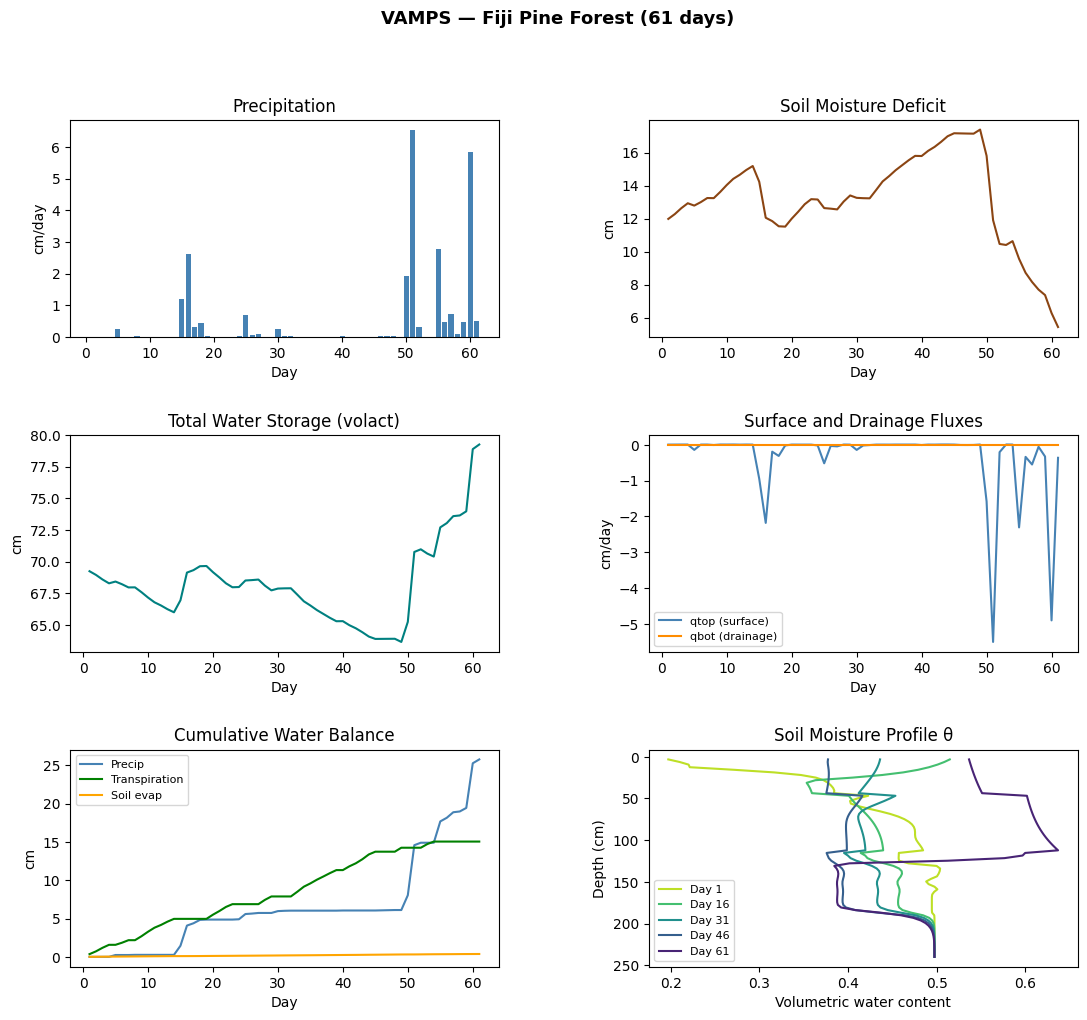

Figure saved to fiji_results.png


In [7]:
nl     = result['_nlayers']   # 77 soil layers
theta  = result['theta']       # (steps, nlayers)
layer_depth = np.arange(1, nl + 1) * (240.0 / nl)   # approximate mid-point depths [cm]

fig = plt.figure(figsize=(13, 11))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- Precipitation ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(days, forcing['pre'], color='steelblue', width=0.8)
ax1.set_title('Precipitation')
ax1.set_ylabel('cm/day')
ax1.set_xlabel('Day')

# --- Soil moisture deficit ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(days, result['SMD'], color='saddlebrown')
ax2.set_title('Soil Moisture Deficit')
ax2.set_ylabel('cm')
ax2.set_xlabel('Day')

# --- Total water storage ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(days, result['volact'], color='teal')
ax3.set_title('Total Water Storage (volact)')
ax3.set_ylabel('cm')
ax3.set_xlabel('Day')

# --- Surface and drainage fluxes ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(days, result['qtop'], label='qtop (surface)', color='steelblue')
ax4.plot(days, result['qbot'], label='qbot (drainage)', color='darkorange')
ax4.set_title('Surface and Drainage Fluxes')
ax4.set_ylabel('cm/day')
ax4.set_xlabel('Day')
ax4.legend(fontsize=8)

# --- Cumulative water balance ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(days, result['cumprec'], label='Precip',        color='steelblue')
ax5.plot(days, result['cumtra'],  label='Transpiration', color='green')
ax5.plot(days, result['cumeva'],  label='Soil evap',     color='orange')
ax5.set_title('Cumulative Water Balance')
ax5.set_ylabel('cm')
ax5.set_xlabel('Day')
ax5.legend(fontsize=8)

# --- Soil moisture profiles at selected days ---
ax6 = fig.add_subplot(gs[2, 1])
colors = plt.cm.viridis_r(np.linspace(0.1, 0.9, 5))
for j, day in enumerate([1, 16, 31, 46, 61]):
    idx = min(day - 1, theta.shape[0] - 1)
    ax6.plot(theta[idx], layer_depth, color=colors[j], label=f'Day {day}')
ax6.invert_yaxis()
ax6.set_title('Soil Moisture Profile θ')
ax6.set_xlabel('Volumetric water content')
ax6.set_ylabel('Depth (cm)')
ax6.legend(fontsize=8)

fig.suptitle('VAMPS — Fiji Pine Forest (61 days)', fontsize=13, fontweight='bold')
plt.savefig('fiji_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to fiji_results.png')

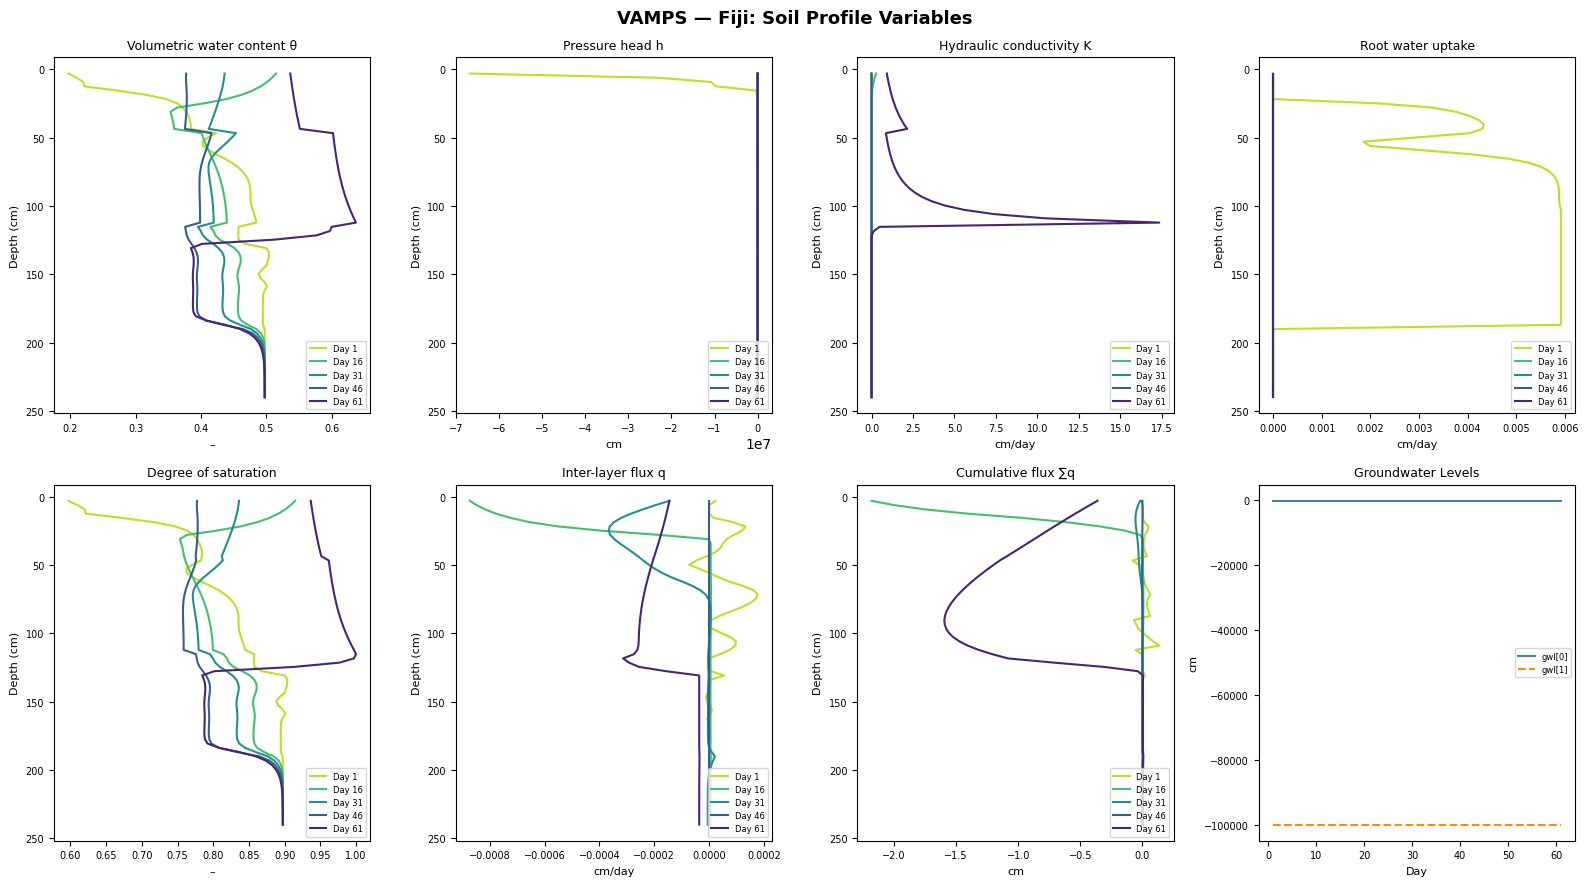

Saved fiji_profiles.png


In [8]:
sel_days = [1, 16, 31, 46, 61]
sel_idx  = [d - 1 for d in sel_days]
colors   = plt.cm.viridis_r(np.linspace(0.1, 0.9, len(sel_days)))

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
fig.suptitle('VAMPS — Fiji: Soil Profile Variables', fontsize=13, fontweight='bold')

profile_specs = [
    (result['theta'],           nl,     'Volumetric water content θ', '–'),
    (result['h'],               nl,     'Pressure head h',            'cm'),
    (result['k'],               nl,     'Hydraulic conductivity K',   'cm/day'),
    (result['qrot'],            nl,     'Root water uptake',          'cm/day'),
    (result['howsat'],          nl,     'Degree of saturation',       '–'),
    (result['q'][:, :nl],      nl,     'Inter-layer flux q',         'cm/day'),
    (result['inq'][:, :nl],    nl,     'Cumulative flux ∑q',         'cm'),
]

for ax, (arr, ncols, title, unit) in zip(axes.flat, profile_specs):
    for j, (idx, day) in enumerate(zip(sel_idx, sel_days)):
        ax.plot(arr[idx, :ncols], layer_depth, color=colors[j], label=f'Day {day}')
    ax.invert_yaxis()
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(unit, fontsize=8)
    ax.set_ylabel('Depth (cm)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6, loc='lower right')

# Groundwater levels time series
ax_gwl = axes.flat[7]
ax_gwl.plot(days, result['gwl'][:, 0], label='gwl[0]', color='steelblue')
ax_gwl.plot(days, result['gwl'][:, 1], label='gwl[1]', color='darkorange', linestyle='--')
ax_gwl.set_title('Groundwater Levels', fontsize=9)
ax_gwl.set_xlabel('Day', fontsize=8)
ax_gwl.set_ylabel('cm', fontsize=8)
ax_gwl.tick_params(labelsize=7)
ax_gwl.legend(fontsize=6)

plt.tight_layout()
plt.savefig('fiji_profiles.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved fiji_profiles.png')

## 5. Soil Profile Variables

In addition to the scalar time-series, the result dict contains full soil profiles
at every timestep:

| Key | Shape | Description |
|-----|-------|-------------|
| `theta` | `(steps, nlayers)` | Volumetric water content |
| `k` | `(steps, nlayers)` | Hydraulic conductivity [cm/day] |
| `h` | `(steps, nlayers)` | Pressure head [cm] |
| `qrot` | `(steps, nlayers)` | Root water uptake [cm/day] |
| `howsat` | `(steps, nlayers)` | Degree of saturation [–] |
| `q` | `(steps, nlayers+1)` | Inter-layer flux [cm/day] |
| `inq` | `(steps, nlayers+1)` | Cumulative inter-layer flux [cm] |
| `gwl` | `(steps, 2)` | Groundwater table levels [cm] |